In [1]:
# Import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import cv2

#keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.utils  import to_categorical
import sklearn.metrics as metrics

2026-02-16 02:14:53.485502: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 02:14:53.524813: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 02:14:54.236877: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# train = pd.read_csv("../CNN_training/emnist/emnist-balanced-train.csv",delimiter = ',')
# test = pd.read_csv("../CNN_training/emnist/emnist-balanced-test.csv", delimiter = ',')
# mapp = pd.read_csv("../CNN_training/emnist/emnist-balanced-mapping.txt", delimiter = ' ', \
#                    index_col=0, header=None)
# print("Train: %s, Test: %s, Map: %s" %(train.shape, test.shape, mapp.shape))

In [3]:
train = pd.read_csv("../CNN_training/emnist/emnist-letters-train.csv",delimiter = ',')
test = pd.read_csv("../CNN_training/emnist/emnist-letters-train.csv", delimiter = ',')
mapp = pd.read_csv("../CNN_training/emnist/emnist-letters-mapping.txt", delimiter = ' ', \
                   index_col=0, header=None)

mapp = mapp.iloc[:, 0]  # convert to Series

print("Train: %s, Test: %s, Map: %s" %(train.shape, test.shape, mapp.shape))

Train: (88799, 785), Test: (88799, 785), Map: (26,)


In [4]:
# Constants
HEIGHT = 28
WIDTH = 28

In [5]:
# Split x and y
# y1 = np.array(training_letter.iloc[:,0].values) - 1
# x1 = np.array(training_letter.iloc[:,1:].values)
# #testing_labels
# y2 = np.array(testing_letter.iloc[:,0].values) - 1
# x2 = np.array(testing_letter.iloc[:,1:].values)
train_x = np.array(train.iloc[:,1:].values) - 1
train_y = np.array(train.iloc[:,0].values) -1
del train

test_x = np.array(test.iloc[:,1:].values) - 1
test_y = np.array(test.iloc[:,0].values) - 1
del test

In [6]:
print(train_x.shape,train_y.shape,test_x.shape,test_y.shape)

(88799, 784) (88799,) (88799, 784) (88799,)


In [7]:
def rotate(image):
    image = image.reshape([HEIGHT, WIDTH])
    image = np.fliplr(image)
    image = np.rot90(image)
    return image

In [8]:
# Flip and rotate image
train_x = np.asarray(train_x)
train_x = np.apply_along_axis(rotate, 1, train_x)
print ("train_x:",train_x.shape)

test_x = np.asarray(test_x)
test_x = np.apply_along_axis(rotate, 1, test_x)
print ("test_x:",test_x.shape)

train_x: (88799, 28, 28)
test_x: (88799, 28, 28)


In [9]:
# Normalise
train_x = train_x.astype('float32')
train_x /= 255
test_x = test_x.astype('float32')
test_x /= 255


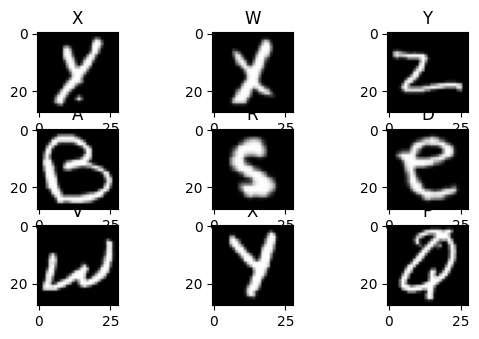

In [10]:
# plot image
for i in range(100, 109):
    plt.subplot(330 + (i+1))
    plt.imshow(train_x[i], cmap=plt.get_cmap('gray'))
    plt.title(chr(mapp[train_y[i]]))

In [11]:
# number of classes
num_classes = len(np.unique(train_y))
# print(len(num_classes))

In [12]:
# One hot encoding
train_y = to_categorical(train_y, num_classes)
test_y = to_categorical(test_y, num_classes)
print("train_y: ", train_y.shape)
print("test_y: ", test_y.shape)

train_y:  (88799, 26)
test_y:  (88799, 26)


In [13]:
# Reshape image for CNN
train_x = train_x.reshape(-1, HEIGHT, WIDTH, 1)
test_x = test_x.reshape(-1, HEIGHT, WIDTH, 1)

In [14]:
# partition to train and val
train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size= 0.10, random_state=7)

In [15]:
# Building model
# ((Si - Fi + 2P)/S) + 1
model = Sequential()

model.add(Conv2D(filters=128, kernel_size=(5,5), padding = 'same', activation='relu',\
                 input_shape=(HEIGHT, WIDTH,1)))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=64, kernel_size=(3,3) , padding = 'same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(.5))
model.add(Dense(units=num_classes, activation='softmax'))

model.summary()

/home/sai/Documents/School/AY2025-2026/T2/THSCE03/THES2/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771179317.369331 1320340 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4958 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 482,010 (1.84 MB)

 Trainable params: 482,010 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [17]:
history = model.fit(train_x, train_y, epochs=10, batch_size=512, verbose=1, \
                    validation_data=(val_x, val_y))

Epoch 1/10


2026-02-16 02:15:22.334015: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f0a38006ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-16 02:15:22.334048: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-02-16 02:15:22.383807: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-16 02:15:22.523373: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-16 02:15:23.194132: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_874', 64 bytes spill stores, 64 bytes spill loads

2026-02-16 02:15:23.339718: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:3

  5/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.0635 - loss: 3.2122

I0000 00:00:1771179326.467807 1321571 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4674 - loss: 1.8114

2026-02-16 02:15:30.779889: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-16 02:15:30.779977: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-16 02:15:30.976497: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_649', 4 bytes spill stores, 4 bytes spill loads

2026-02-16 02:15:30.976709: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4696 - loss: 1.8036

2026-02-16 02:15:34.552717: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-16 02:15:34.814090: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_112', 16 bytes spill stores, 16 bytes spill loads

2026-02-16 02:15:35.157860: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_112', 420 bytes spill stores, 420 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.6405 - loss: 1.1992 - val_accuracy: 0.8743 - val_loss: 0.3907
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8308 - loss: 0.5394 - val_accuracy: 0.9063 - val_loss: 0.2863
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8639 - loss: 0.4321 - val_accuracy: 0.9113 - val_loss: 0.2621
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8805 - loss: 0.3751 - val_accuracy: 0.9199 - val_loss: 0.2362
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8918 - loss: 0.3355 - val_accuracy: 0.9256 - val_loss: 0.2185
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8992 - loss: 0.3101 - val_accuracy: 0.9283 - val_loss: 0.2121
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9047 - loss: 0.2934 - val_accuracy: 0.9325 - val_loss: 0.2026
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9100 - loss: 0.2755 - val_accuracy: 0.93

In [26]:
model.save("hwv1.keras")

In [18]:
# plot accuracy and loss
def plotgraph(epochs, acc, val_acc):
    # Plot training & validation accuracy values
    plt.plot(epochs, acc, 'b')
    plt.plot(epochs, val_acc, 'r')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()

In [20]:
#%%
# acc = history.history['acc']
# val_acc = history.history['val_acc']
# loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs = range(1,len(acc)+1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

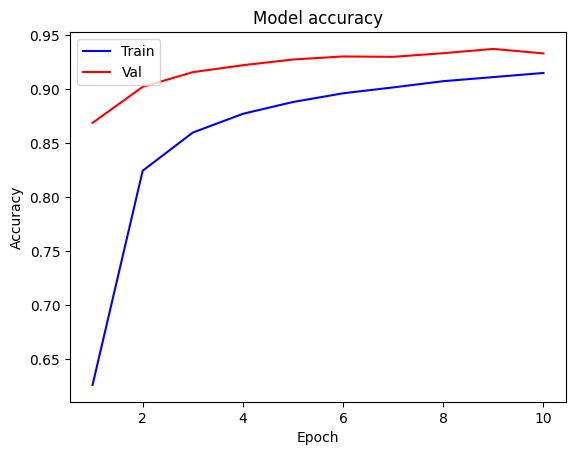

In [21]:
# Accuracy curve
plotgraph(epochs, acc, val_acc)

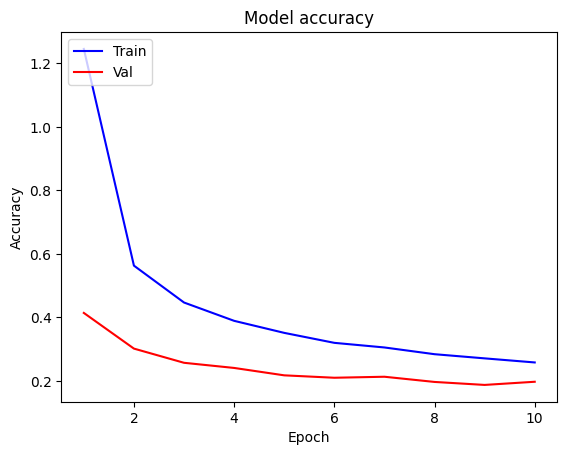

In [22]:
# loss curve
plotgraph(epochs, loss, val_loss)

In [23]:
score = model.evaluate(test_x, test_y, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

2026-02-16 01:38:44.324966: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_112', 20 bytes spill stores, 20 bytes spill loads



Test loss: 0.14729714393615723
Test accuracy: 0.9480850100517273


In [24]:
y_pred = model.predict(test_x)
y_pred = (y_pred > 0.5)

2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [25]:
cm = metrics.confusion_matrix(test_y.argmax(axis=1), y_pred.argmax(axis=1))